In [62]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

import numpy as np
from datetime import datetime

# # # # # # # # # # # # # # #
save = True
fp_type = 'morgan'
cnts = False
bits = 1024
r = 2
dist_type = 'euclidean'
# # # # # # # # # # # # # # #

today = datetime.today().strftime('%Y%m%d%H')

if cnts==False:
    c = 'bitv'
elif cnts==True:
    c = 'cntv'
    
if dist_type=='euclidean':
    d = 'eucnorm'
    
v = '_'.join(['baseline','2000n_test',fp_type,c,f'{bits}b',f'{r}r',d])
tag = f'{today}_{v}'
print(tag)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2022050311_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm


## 1) Get anc-aug map.

In [63]:
rdir = '/home/kat/Repos/SALSA/results/'
mdir = '/home/kat/Repos/SALSA/data/model_ready/'

In [64]:
from eval_functions import *

which_test = '01'
which_train = '01'

anc_path = f'{mdir}{which_test}/test/anchor_smiles.csv'
aug_path = f'{mdir}{which_test}/test/augmented_smiles.csv'   
anc_map = get_anc_map( get_dataset_array(anc_path, aug_path) )

## 2) Load model UMAP for consistent ordering of coords (?) Calculate fps.

In [65]:
# Which evaluation set? ...
# # # # # # # # # # # 
umap_tag = '2022041809_a04_2000n_test_32neigh_mindist0pt1'
# # # # # # # # # # # 

import pandas as pd
from utilities.fp_utils import get_fps_in_parallel
import numpy as np
from sklearn import preprocessing

df = pd.read_csv(f'{rdir}umap_dfs/{umap_tag}.csv', usecols=["Smiles","Label","Atype"])
display(df)

fps = get_fps_in_parallel(df.Smiles,fp_type,counts=cnts,bits=bits,)
fps = np.stack(fps)

if dist_type=='euclidean':
    fps = preprocessing.normalize(fps, norm='l2', axis=1)
print(fps.shape)

,Smiles,Atype,Label
0,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C1NC(=O)NC(=O)C1F...,Anc,0
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,Anc,1
2,c1ccc(-c2nnc(N3CCOCC3)c3ccccc23)cc1,Anc,2
3,NC1(C(=O)O)CCc2cc(N(CCCl)CCCl)ccc2C1,Anc,3
4,Cc1ncoc1-c1nnc(SCCCNC2CC3CC3(c3ccccc3)C2)n1C,Anc,4
...,...,...,...
11995,CC(Cn1nnc2ccccc2c1=O)C(=O)NCC1CCC(C(=O)O)CC1,Aug,1999
11996,Cc1ccc2c(=O)n(CCC(=O)NCC3CCC(C(=O)O)CC3)nnc2c1,Aug,1999
11997,NC1(CNC(=O)CCn2nnc3ccccc3c2=O)CCC(C(=O)O)CC1,Aug,1999
11998,CC(NC(=O)CCn1nnc2ccccc2c1=O)C1CCC(C(=O)O)CC1,Aug,1999


(12000, 1024)


In [66]:
df[df.Label==1749]

,Smiles,Atype,Label
1749,C=C(O)C(=O)C(COC(C)=O)OC(C)=O,Anc,1749
10745,C=C(O)C(=O)C(C)(COC(C)=O)OC(C)=O,Aug,1749
10746,CC=C(O)C(=O)C(COC(C)=O)OC(C)=O,Aug,1749
10747,C=C(O)C(=O)C(OC(C)=O)C(C)OC(C)=O,Aug,1749
10748,C=C(OO)C(=O)C(COC(C)=O)OC(C)=O,Aug,1749
10749,C=C(O)C(=O)C(COC(=O)CO)OC(C)=O,Aug,1749


## 3) Get distances. Save file.

In [67]:
from tqdm.notebook import tqdm
from scipy.spatial import distance
from itertools import combinations as combo

anc_aug_dists = []
far = []
for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
    augs = list(augs)
    augs.pop(0)
    
    fp_anc = fps[anc]    
    for aug in augs:
        fp_aug = fps[aug]
        
        if dist_type=='tanimoto':
            d = distance.rogerstanimoto(fp_anc, fp_aug)
        elif dist_type=='jaccard':
            d = distance.jaccard(fp_anc, fp_aug)
        elif dist_type=='euclidean':
            d = distance.euclidean(fp_anc, fp_aug)
            
        if d > 0.95:
            print(d,anc,aug)
            far.append(anc)
        anc_aug_dists.append(d)
        
dist_arr = np.array(anc_aug_dists)        
if save:
    txt_out = f'{rdir}anc_aug_dists/{tag}.txt'
    np.savetxt(txt_out, dist_arr)

  0%|          | 0/2000 [00:00<?, ?it/s]

0.9881636345067967 147 2735
0.9559509893804409 510 4554
1.0076051171790157 545 4725
0.9759252772456534 545 4728
0.9528704988276759 858 6294
0.9801885101645874 918 6590
0.9801885101645874 918 6594
1.019726082318989 1005 7029
0.9994825354025761 1380 8901
0.9775142271424049 1474 9371
0.953368002829987 1492 9460
0.9711890142835451 1749 10745


In [68]:
far

[147, 510, 545, 545, 858, 918, 918, 1005, 1380, 1474, 1492, 1749]

## 4) Plot histogram.

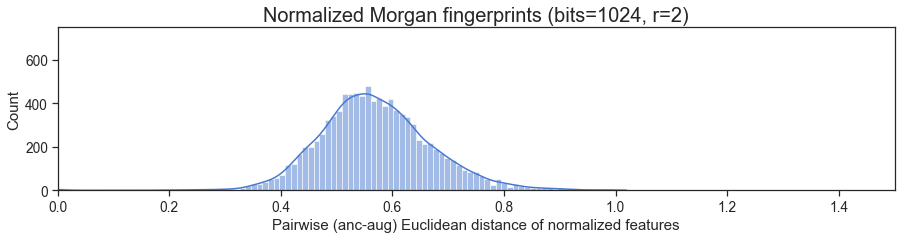

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

bns = 100
ylim = 750

t = f'Normalized Morgan fingerprints (bits=1024, r=2)' #, {bns} bins)'

plt.figure(figsize=(15,3))
plt.title(t,fontsize=20)
plt.ylim(0,ylim)
plt.xlim(0,1.5)

sns.histplot(anc_aug_dists, kde=True, bins=bns) #bins=100)

if dist_type=='tanimoto':
    plt.xlabel('Pairwise (anc-aug) Tanimoto distance of descriptors')
elif dist_type=='jaccard':
    plt.xlabel('Pairwise (anc-aug) Jaccard distance of descriptors')
elif dist_type=='euclidean':
    plt.xlabel('Pairwise (anc-aug) Euclidean distance of normalized features')
    
# plt.savefig(f'{rdir}plot_figs/{tag}_{bns}bins_ylim{ylim}.png', bbox_inches='tight')
plt.show()

## 5) Calculate and plot UMAP projection.

In [70]:
import umap.umap_ as umap
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import random

def get_umap_coords(tag_emb, df, latents, n_neighs, min_dist, 
                    save_coords=True, save_plot=True, show_plot=True):
 
    rdir = '/home/kat/Repos/SALSA/results/'
    
    pt = str(min_dist).split('.')[1]
    tag_coords = '_'.join([tag_emb, f'{n_neighs}neigh', f'mindist0pt{pt}'])
    print(f"Tag is {tag_coords}!")
    
    umapper = umap.UMAP(n_neighbors=n_neighs, min_dist=min_dist, 
                        n_components=2, metric='euclidean')
    embedding = umapper.fit_transform(latents)

    df['x'] = embedding[:, 0]
    df['y'] = embedding[:, 1]

    if save_coords:
        csv_out = f'{rdir}umap_dfs/{tag_coords}.csv'
        df.to_csv(csv_out,index=False)
        print(f"Saved smiles and coords to {csv_out}!")
        
    sns.set_theme(style='ticks',font_scale=1.5)
    plt.figure(figsize=(10,10))
    sns.scatterplot(data=df[df['Atype']=='Aug'], x='x', y='y', hue='Atype', 
                    alpha=0.5, s=10, palette={'Aug':'red'})
    sns.scatterplot(data=df[df['Atype']=='Anc'], x='x', y='y', hue='Atype', 
                    alpha=1., s=7, palette={'Anc':'blue'})
        
    if save_plot:
        png_out = f'{rdir}umap_figs/{tag_coords}.png'
        plt.savefig(png_out, bbox_inches='tight')
        print(f"Saved umap plot to {png_out}!")
    if show_plot:
        plt.show()
        
    return df

Tag is 2022050311_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1!
Saved smiles and coords to /home/kat/Repos/SALSA/results/umap_dfs/2022050311_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1.csv!
Saved umap plot to /home/kat/Repos/SALSA/results/umap_figs/2022050311_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm_32neigh_mindist0pt1.png!


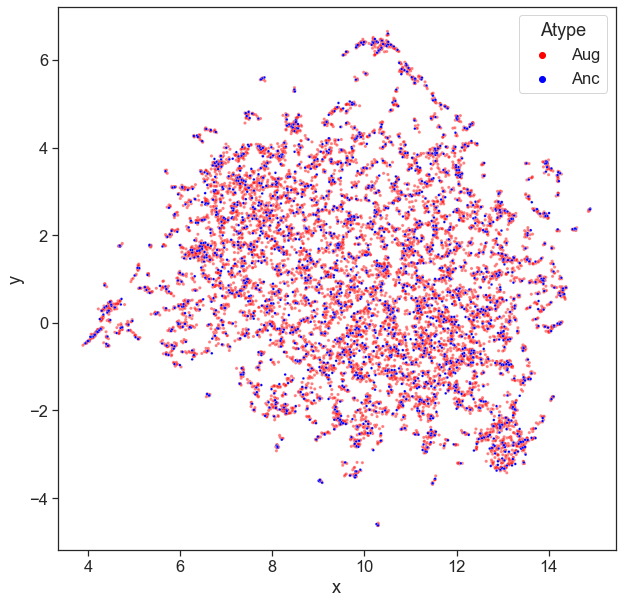

In [71]:
df_umap = get_umap_coords(tag_emb=tag, df=df, latents=fps, n_neighs=32, min_dist=0.1, 
                          save_coords=True, save_plot=True, show_plot=True)

In [72]:
df_umap

,Smiles,Atype,Label,x,y
0,CC(C)CC(NC(=O)C(CC(C)C)NC(=O)C1NC(=O)NC(=O)C1F...,Anc,0,5.759323,0.713623
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,Anc,1,9.171251,1.061435
2,c1ccc(-c2nnc(N3CCOCC3)c3ccccc23)cc1,Anc,2,8.417086,4.479909
3,NC1(C(=O)O)CCc2cc(N(CCCl)CCCl)ccc2C1,Anc,3,7.413748,-0.286128
4,Cc1ncoc1-c1nnc(SCCCNC2CC3CC3(c3ccccc3)C2)n1C,Anc,4,8.479802,5.321835
...,...,...,...,...,...
11995,CC(Cn1nnc2ccccc2c1=O)C(=O)NCC1CCC(C(=O)O)CC1,Aug,1999,10.416979,3.412035
11996,Cc1ccc2c(=O)n(CCC(=O)NCC3CCC(C(=O)O)CC3)nnc2c1,Aug,1999,10.263609,3.232634
11997,NC1(CNC(=O)CCn2nnc3ccccc3c2=O)CCC(C(=O)O)CC1,Aug,1999,10.289282,3.294038
11998,CC(NC(=O)CCn1nnc2ccccc2c1=O)C1CCC(C(=O)O)CC1,Aug,1999,10.510844,3.384629


In [82]:
from tqdm.notebook import tqdm
from scipy.spatial import distance
from itertools import combinations as combo

umap_anc_aug_dists = []
far = []
for anc,augs in tqdm(anc_map.items(), total=len(anc_map)):
    augs = list(augs)
    augs.pop(0)
    
    x_anc = df_umap.loc[anc,'x']   
    y_anc = df_umap.loc[anc,'y'] 
    coord_anc = [x_anc, y_anc]
#     print(x_anc)
    for aug in augs:
        x_aug = df_umap.loc[aug,'x']   
        y_aug = df_umap.loc[aug,'y'] 
        coord_aug = [x_aug, y_aug]
        d = distance.euclidean(coord_anc, coord_aug)
            
        if d > 0.95:
            print(d,anc,aug)
            far.append(anc)
        umap_anc_aug_dists.append(d)
        
dist_arr = np.array(anc_aug_dists)        

  0%|          | 0/2000 [00:00<?, ?it/s]

5.065352916717529 809 6046
1.360428810119629 1075 7379
6.815085411071777 1753 10766
0.9718878269195557 1898 11494


In [81]:
sorted(dist_arr, reverse=True)

[1.019726082318989,
 1.0076051171790157,
 0.9994825354025761,
 0.9881636345067967,
 0.9801885101645874,
 0.9801885101645874,
 0.9775142271424049,
 0.9759252772456534,
 0.9711890142835451,
 0.9559509893804409,
 0.953368002829987,
 0.9528704988276759,
 0.9411843448218254,
 0.9306108272846286,
 0.9301972751910423,
 0.9258200997725515,
 0.9255679872650853,
 0.9194016867619662,
 0.9187812668783543,
 0.9180004767342502,
 0.9175336242954957,
 0.9154807459131922,
 0.9123153409213184,
 0.9113895082215612,
 0.9072046226331746,
 0.9038578629947553,
 0.9038578629947553,
 0.9013878188659973,
 0.901065891589859,
 0.9008606083445252,
 0.9000965764506694,
 0.8978173469078115,
 0.8976843164202746,
 0.8938897283568297,
 0.8935866950821161,
 0.8933286098813252,
 0.8901015224618574,
 0.8890278547278414,
 0.8887257534992918,
 0.8863670337744785,
 0.8863670337744785,
 0.8845794623039007,
 0.8840002309446051,
 0.8828848698910529,
 0.8804857344718375,
 0.8798826901281198,
 0.8793317245248636,
 0.8770580193070